In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/data/heart_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#General Health, Mental Health and Healthcare Access

## Overview

This section analyzes how general health, mental health, and access to healthcare services relate to heart disease. Unlike direct medical conditions, these variables capture preventative behaviors and self-reported well being. The goal is to see patterns in how lifestyle awareness and healthcare access influence heart disease risk.:


In [5]:
health_cols = [
    'GeneralHealth',
    'MentalHealthDays',
    'LastCheckupTime',
    'ChestScan',
    'HIVTesting',
    'FluVaxLast12',
    'PneumoVaxEver',
    'TetanusLast10Tdap',
    'HighRiskLastYear',
    'CovidPos'
]

target = 'HadHeartDisease'

analysis_df = data[health_cols + [target]].dropna()
analysis_df.head()

,GeneralHealth,MentalHealthDays,LastCheckupTime,ChestScan,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartDisease
0,Very good,0.0,Within past year (anytime less than 12 months ...,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,Excellent,0.0,Unknown,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,Very good,3.0,Within past year (anytime less than 12 months ...,No,No,No,No,Unknown,No,Yes,0
3,Excellent,0.0,Within past year (anytime less than 12 months ...,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,Fair,0.0,Within past year (anytime less than 12 months ...,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0


# 1. Preventative Care vs Heart Disease

Are health checkups indicative of heart disease? Do the people take vax?

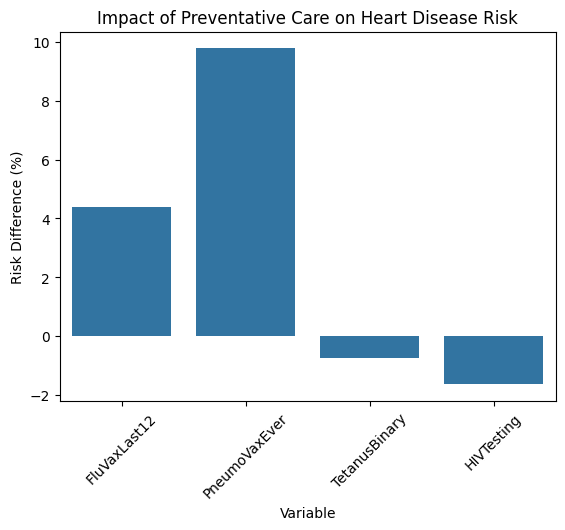

In [11]:
analysis_df['TetanusBinary'] = analysis_df['TetanusLast10Tdap'].apply(
    lambda x: 'Yes' if 'Yes' in x else ('No' if 'No' in x else None)
)
# make everything yes or no only
preventative = ['FluVaxLast12', 'PneumoVaxEver', 'TetanusBinary', 'HIVTesting']
screening = ['ChestScan', 'LastCheckupTime']
risk_results = []

for col in preventative:
    risk_yes = analysis_df[analysis_df[col] == 'Yes'][target].mean()
    risk_no = analysis_df[analysis_df[col] == 'No'][target].mean()

    risk_results.append({
        'Variable': col,
        'Risk Difference (%)': (risk_yes - risk_no) * 100
    })

results_df = pd.DataFrame(risk_results)

sns.barplot(data=results_df, x='Variable', y='Risk Difference (%)')
plt.xticks(rotation=45)
plt.title("Impact of Preventative Care on Heart Disease Risk")
plt.show()

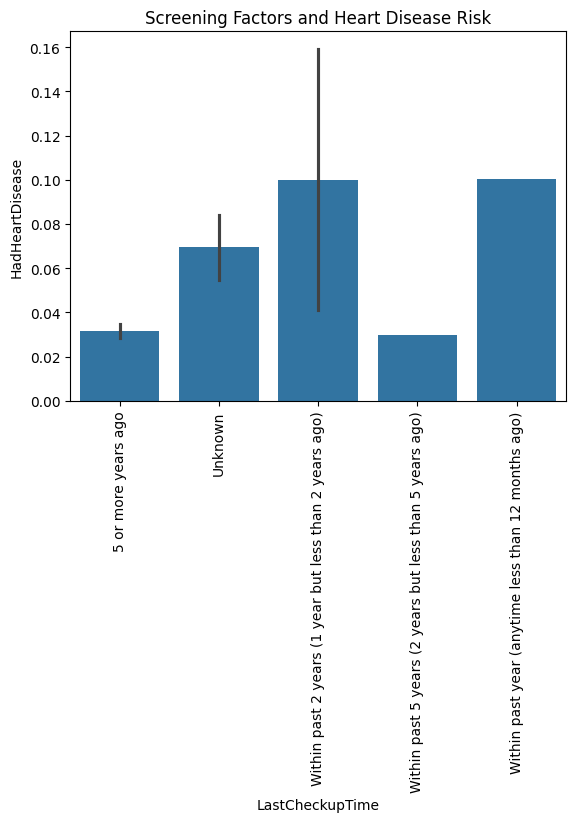

In [22]:
screening_results = []

for col in screening:
    grouped = analysis_df.groupby(col)[target].mean().reset_index()
    grouped['Variable'] = col
    screening_results.append(grouped)

screening_df = pd.concat(screening_results)

sns.barplot(
    data=screening_df,
    x=col,
    y=target
)
plt.title("Screening Factors and Heart Disease Risk")
plt.xticks(rotation=90)
plt.show()

# 2. Mental Health Impact

How many mental health days did a person take?

/tmp/ipykernel_2967/2613411227.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mental_risk = analysis_df.groupby('MentalHealthLevel')[target].mean()


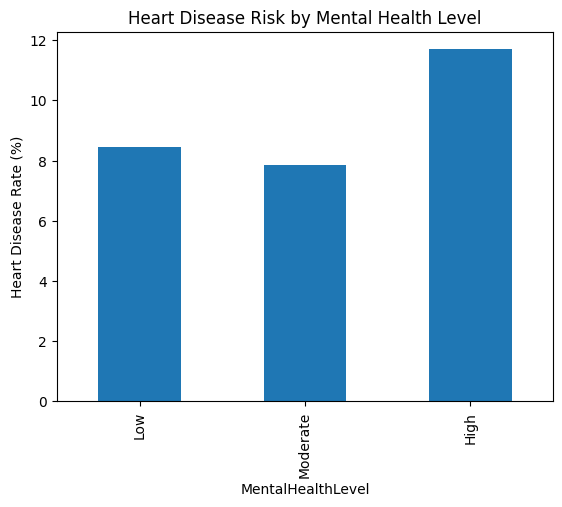

In [15]:
analysis_df['MentalHealthLevel'] = pd.cut(
    analysis_df['MentalHealthDays'],
    bins=[-1, 5, 15, 30],
    labels=['Low', 'Moderate', 'High']
)

mental_risk = analysis_df.groupby('MentalHealthLevel')[target].mean()
mental_risk_percent = mental_risk * 100
mental_risk_percent.plot(kind='bar')
plt.ylabel("Heart Disease Rate (%)")
plt.title("Heart Disease Risk by Mental Health Level")
plt.show()

Text(0.5, 1.0, 'Heart Disease Rate by General Health')

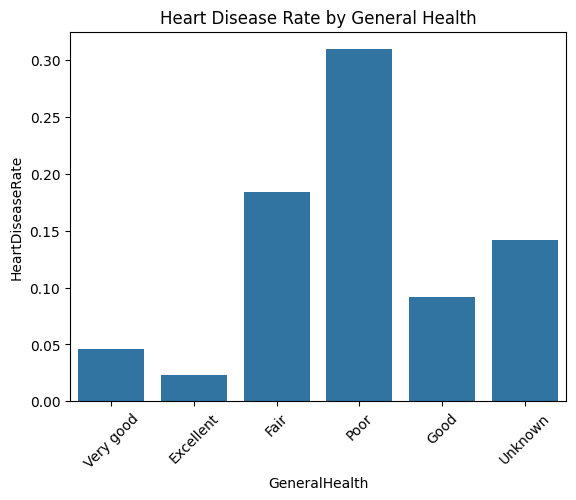

In [20]:
results = []

for health in analysis_df['GeneralHealth'].unique():
    subset = analysis_df[analysis_df['GeneralHealth'] == health]
    risk = subset[target].mean()

    results.append({
        'GeneralHealth': health,
        'HeartDiseaseRate': risk
    })

health_df = pd.DataFrame(results)
sns.barplot(data=health_df, x='GeneralHealth', y='HeartDiseaseRate')
plt.xticks(rotation=45)
plt.title("Heart Disease Rate by General Health")

## Analysis

The strongest relationship was in general health and mental health. Individuals reporting poor overall health had significantly higher heart disease rates compared to those reporting excellent health.

Screening and healthcare utilization variables, like as recent checkups and chest scans, showed that individuals who interact more frequently with healthcare systems tend to have higher observed heart disease rates. This likely reflects reverse causality, where individuals with existing health conditions seek care more often.

Mental health analysis revealed that individuals with a high number of poor mental health days have increased rates of heart disease compared to those with fewer mental health challenges. This may be partially explained by chronic stress responses. Prolonged stress has been associated with high cortisol levels and increased blood pressure which are known risk factors for cardiovascular disease.